# Technoeconomic Analysis with Differentiable Flowsheets

This notebook demonstrates comprehensive **Technoeconomic Analysis (TEA)** integrated with JAX-based process simulation. All calculations are fully differentiable, enabling gradient-based optimization of process economics.

## What You'll Learn

1. **Equipment Sizing & Capital Costs** - Cost correlations for reactors, heat exchangers, etc.
2. **Operating Costs** - Utilities, raw materials, labor, maintenance
3. **Profitability Metrics** - NPV, IRR, MSP, payback period
4. **Gradient-Based Optimization** - Maximize profit using autodiff
5. **Sensitivity Analysis** - Understand how parameters affect economics

## Process Overview

We analyze a simple CSTR process:
- **Reaction:** A → B (first-order, exothermic)
- **Design Variables:** Reactor volume (V), Temperature (T)
- **Objective:** Maximize annual profit

In [1]:
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax
import jax.numpy as jnp
from jax import Array
jax.config.update("jax_enable_x64", True)

# Process simulation imports
from difflow.streams import make_stream, get_flows
from difflow.thermo import IdealThermo, SpeciesData
from difflow.units.cstr import CSTR, CSTRParams

# Economics imports
import difflow.economics as econ

print("Imports successful!")

W0000 00:00:1765976220.253401 13762273 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1765976220.261687 13762273 service.cc:145] XLA service 0x600000d28300 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765976220.261696 13762273 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1765976220.262694 13762273 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1765976220.262702 13762273 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


Imports successful!


## 1. Process Setup

Define the reaction system: **A → B** with Arrhenius kinetics

$$r = A \cdot e^{-E_a/RT} \cdot C_A$$

where:
- $A = 10^6$ s⁻¹ (pre-exponential factor)
- $E_a = 50$ kJ/mol (activation energy)
- $\Delta H_{rxn} = -50$ kJ/mol (exothermic)

In [2]:
# Define species thermodynamic properties
species_data = {
    "A": SpeciesData(
        name="A", MW=100.0, Cp_coeffs=(75.0, 0.0, 0.0, 0.0),
        Hvap_coeffs=(35000.0, 0.38, 500.0), antoine_coeffs=(10.0, 3000.0, -50.0),
        Hf=0.0,
    ),
    "B": SpeciesData(
        name="B", MW=100.0, Cp_coeffs=(75.0, 0.0, 0.0, 0.0),
        Hvap_coeffs=(30000.0, 0.38, 450.0), antoine_coeffs=(10.0, 2800.0, -40.0),
        Hf=-50000.0,  # Exothermic reaction
    ),
}

thermo = IdealThermo(species_data)
species_order = ["A", "B"]
stoichiometry = jnp.array([[-1.0], [+1.0]])  # A consumed, B produced

def rate_function(C: dict[str, Array], T: Array, params: dict) -> Array:
    """First-order reaction: A → B with Arrhenius kinetics."""
    k = params["A"] * jnp.exp(-params["Ea"] / (8.314 * T))
    return jnp.array([k * C["A"]])

# Kinetic parameters
kinetic_params = {
    "A": jnp.array(1e6),      # Pre-exponential (1/s)
    "Ea": jnp.array(50000.0),  # Activation energy (J/mol)
}

print("Process setup complete!")
print(f"  Pre-exponential factor: {float(kinetic_params['A']):.0e} 1/s")
print(f"  Activation energy: {float(kinetic_params['Ea'])/1000:.0f} kJ/mol")

Process setup complete!
  Pre-exponential factor: 1e+06 1/s
  Activation energy: 50 kJ/mol


## 2. Integrated Process Economics Model

We create a class that combines process simulation with economic calculations. This enables computing profit, NPV, and other metrics as differentiable functions of design variables.

In [3]:
class ProcessEconomics:
    """Integrated process simulation with economics.
    
    All methods are JAX-differentiable for optimization.
    """
    
    def __init__(
        self,
        feed_rate: float = 10.0,  # mol/s of A
        feed_temp: float = 300.0,  # K
        prices: dict | None = None,
    ):
        self.feed_rate = feed_rate
        self.feed_temp = feed_temp
        
        # Economic parameters
        self.prices = prices or {
            "A": 50.0,   # $/kmol raw material A
            "B": 200.0,  # $/kmol product B
        }
        
        # Operating parameters
        self.hours_per_year = 8000.0
        self.seconds_per_year = self.hours_per_year * 3600.0
    
    def simulate(self, V: Array, T: Array) -> tuple[dict, dict]:
        """Run reactor simulation."""
        params = CSTRParams(
            V=V,
            rate_fn=rate_function,
            stoich=stoichiometry,
            rate_params=kinetic_params,
            species_order=species_order,
            dH_rxn=jnp.array([-50000.0]),
        )
        cstr = CSTR(params, thermo=thermo, mode="isothermal")
        
        inlet = make_stream(
            {"A": self.feed_rate, "B": 0.0},
            T=self.feed_temp,
            P=101325.0
        )
        
        outlet, info = cstr(inlet, T_spec=T)
        return outlet, info
    
    def capital_cost(self, V: Array) -> dict[str, Array]:
        """Calculate capital costs."""
        # Reactor cost (jacketed CSTR)
        reactor_purchased = econ.reactor_cost(V, "cstr_jacketed")
        
        # Installed costs with Lang factor
        reactor_installed = econ.installed_cost(reactor_purchased, lang_factor=4.74)
        
        # Auxiliary equipment (pumps, piping) = 30% of reactor
        auxiliary = reactor_installed * 0.30
        total_installed = reactor_installed + auxiliary
        
        # Working capital = 15% of FCI
        working_capital = total_installed * 0.15
        
        return {
            "reactor_purchased": reactor_purchased,
            "reactor_installed": reactor_installed,
            "auxiliary": auxiliary,
            "total_installed": total_installed,
            "working_capital": working_capital,
            "total_capital": total_installed + working_capital,
        }
    
    def operating_cost(self, V: Array, T: Array, outlet: dict, info: dict) -> dict[str, Array]:
        """Calculate operating costs ($/year)."""
        # Raw material cost
        raw_material_per_s = self.feed_rate * self.prices["A"] / 1000  # $/s
        raw_material_annual = raw_material_per_s * self.seconds_per_year
        
        # Utility cost (cooling for exothermic reaction)
        Q = jnp.abs(info["Q"])  # Heat duty (W)
        utility_per_s = econ.cooling_water_cost(Q)
        utility_annual = utility_per_s * self.seconds_per_year
        
        # Labor, maintenance, overhead (from FCI)
        capex = self.capital_cost(V)
        fci = capex["total_installed"]
        
        labor_annual = fci * 0.02       # 2% of FCI
        maintenance_annual = fci * 0.04  # 4% of FCI
        overhead_annual = fci * 0.02     # 2% of FCI
        
        total_opex = (
            raw_material_annual + utility_annual +
            labor_annual + maintenance_annual + overhead_annual
        )
        
        return {
            "raw_materials": raw_material_annual,
            "utilities": utility_annual,
            "labor": labor_annual,
            "maintenance": maintenance_annual,
            "overhead": overhead_annual,
            "total_opex": total_opex,
        }
    
    def revenue(self, outlet: dict) -> dict[str, Array]:
        """Calculate annual revenue ($/year)."""
        F_B_out = outlet["F_B"]  # mol/s
        revenue_per_s = F_B_out * self.prices["B"] / 1000  # $/s
        revenue_annual = revenue_per_s * self.seconds_per_year
        
        return {"product_revenue": revenue_annual}
    
    def annual_profit(self, V: Array, T: Array) -> Array:
        """Calculate annual profit (differentiable)."""
        outlet, info = self.simulate(V, T)
        
        capex = self.capital_cost(V)
        opex = self.operating_cost(V, T, outlet, info)
        rev = self.revenue(outlet)
        
        # Annualized capital cost (10% discount rate, 20 year life)
        crf = econ.capital_recovery_factor(jnp.array(0.10), jnp.array(20.0))
        annual_capex = capex["total_capital"] * crf
        
        profit = rev["product_revenue"] - opex["total_opex"] - annual_capex
        return profit
    
    def npv(self, V: Array, T: Array, discount_rate: float = 0.10, plant_life: int = 20) -> Array:
        """Calculate Net Present Value."""
        outlet, info = self.simulate(V, T)
        
        capex = self.capital_cost(V)
        opex = self.operating_cost(V, T, outlet, info)
        rev = self.revenue(outlet)
        
        # Annual cash flow
        annual_cf = rev["product_revenue"] - opex["total_opex"]
        cash_flows = jnp.ones(plant_life) * annual_cf
        
        # Add working capital recovery in final year
        cash_flows = cash_flows.at[-1].add(capex["working_capital"])
        
        return econ.npv(cash_flows, jnp.array(discount_rate), capex["total_capital"])
    
    def minimum_selling_price(self, V: Array, T: Array) -> Array:
        """Calculate minimum selling price for breakeven ($/kmol)."""
        outlet, info = self.simulate(V, T)
        
        capex = self.capital_cost(V)
        opex = self.operating_cost(V, T, outlet, info)
        
        # Annualized capital
        crf = econ.capital_recovery_factor(jnp.array(0.10), jnp.array(20.0))
        annual_capex = capex["total_capital"] * crf
        
        total_annual_cost = opex["total_opex"] + annual_capex
        
        # Annual production of B
        F_B_out = outlet["F_B"]  # mol/s
        annual_production = F_B_out * self.seconds_per_year / 1000  # kmol/year
        
        return total_annual_cost / jnp.maximum(annual_production, 1e-10)

print("ProcessEconomics class defined!")

ProcessEconomics class defined!


## 3. Basic Technoeconomic Analysis

Let's analyze a base case design with V = 2 m³ and T = 400 K.

In [4]:
pe = ProcessEconomics()

# Base case design
V = jnp.array(2.0)   # m³
T = jnp.array(400.0)  # K

print(f"Base Case: V = {float(V):.1f} m³, T = {float(T):.0f} K")
print("=" * 50)

# Simulate
outlet, info = pe.simulate(V, T)
conversion = float(info["conversion"]["A"]) * 100
print(f"\nProcess Performance:")
print(f"  Conversion: {conversion:.1f}%")
print(f"  Heat duty: {float(info['Q'])/1000:.1f} kW (cooling required)")
print(f"  Product rate: {float(outlet['F_B']):.2f} mol/s = {float(outlet['F_B'])*3600/1000:.1f} kmol/hr")

Base Case: V = 2.0 m³, T = 400 K



Process Performance:
  Conversion: 74.7%
  Heat duty: -298.6 kW (cooling required)
  Product rate: 7.47 mol/s = 26.9 kmol/hr


In [5]:
# Capital costs breakdown
capex = pe.capital_cost(V)

print("Capital Costs:")
print("-" * 50)
print(f"  Reactor (purchased):   ${float(capex['reactor_purchased']):>12,.0f}")
print(f"  Reactor (installed):   ${float(capex['reactor_installed']):>12,.0f}")
print(f"  Auxiliary equipment:   ${float(capex['auxiliary']):>12,.0f}")
print(f"  Working capital:       ${float(capex['working_capital']):>12,.0f}")
print("-" * 50)
print(f"  TOTAL CAPITAL:         ${float(capex['total_capital']):>12,.0f}")

Capital Costs:
--------------------------------------------------
  Reactor (purchased):   $      23,101
  Reactor (installed):   $     109,499
  Auxiliary equipment:   $      32,850
  Working capital:       $      21,352
--------------------------------------------------
  TOTAL CAPITAL:         $     163,701


In [6]:
# Operating costs breakdown
opex = pe.operating_cost(V, T, outlet, info)

print("Operating Costs ($/year):")
print("-" * 50)
print(f"  Raw materials:         ${float(opex['raw_materials']):>12,.0f}")
print(f"  Utilities:             ${float(opex['utilities']):>12,.0f}")
print(f"  Labor:                 ${float(opex['labor']):>12,.0f}")
print(f"  Maintenance:           ${float(opex['maintenance']):>12,.0f}")
print(f"  Overhead:              ${float(opex['overhead']):>12,.0f}")
print("-" * 50)
print(f"  TOTAL OPEX:            ${float(opex['total_opex']):>12,.0f}")

Operating Costs ($/year):
--------------------------------------------------
  Raw materials:         $  14,400,000
  Utilities:             $       3,009
  Labor:                 $       2,847
  Maintenance:           $       5,694
  Overhead:              $       2,847
--------------------------------------------------
  TOTAL OPEX:            $  14,414,397


In [7]:
# Revenue and profitability
rev = pe.revenue(outlet)
profit = pe.annual_profit(V, T)
npv_val = pe.npv(V, T)
msp = pe.minimum_selling_price(V, T)

print("Revenue & Profitability:")
print("-" * 50)
print(f"  Product B sales:       ${float(rev['product_revenue']):>12,.0f}/year")
print(f"  Annual Profit:         ${float(profit):>12,.0f}/year")
print(f"  NPV (10%, 20yr):       ${float(npv_val):>12,.0f}")
print(f"  MSP (breakeven):       ${float(msp):>12.2f}/kmol")
print(f"  Current price:         ${pe.prices['B']:>12.2f}/kmol")
print(f"  Margin:                ${pe.prices['B'] - float(msp):>12.2f}/kmol")

Revenue & Profitability:
--------------------------------------------------
  Product B sales:       $  43,033,067/year
  Annual Profit:         $  28,599,441/year
  NPV (10%, 20yr):       $ 243,486,341
  MSP (breakeven):       $       67.08/kmol
  Current price:         $      200.00/kmol
  Margin:                $      132.92/kmol


## 4. Equipment Cost Correlations

The `difflow.economics` module provides cost correlations for various equipment types, all updated to 2024 dollars using CEPCI indices.

In [8]:
print("Reactor Costs (2024 $, installed with Lang factor 4.74):")
print("-" * 60)
print(f"{'Volume (m³)':>12} {'Purchased ($)':>15} {'Installed ($)':>15}")
print("-" * 60)
for V_val in [0.5, 1.0, 2.0, 5.0, 10.0]:
    purchased = econ.reactor_cost(jnp.array(V_val), "cstr_jacketed")
    installed = econ.installed_cost(purchased)
    print(f"{V_val:>12.1f} {float(purchased):>15,.0f} {float(installed):>15,.0f}")

Reactor Costs (2024 $, installed with Lang factor 4.74):
------------------------------------------------------------
 Volume (m³)   Purchased ($)   Installed ($)
------------------------------------------------------------
         0.5          22,971         108,884
         1.0          23,018         109,103
         2.0          23,101         109,499
         5.0          23,322         110,547
        10.0          23,650         112,101


In [9]:
print("\nHeat Exchanger Costs (Shell & Tube, Floating Head):")
print("-" * 60)
print(f"{'Area (m²)':>12} {'Purchased ($)':>15} {'Installed ($)':>15}")
print("-" * 60)
for A_val in [10, 50, 100, 500, 1000]:
    purchased = econ.heat_exchanger_cost(jnp.array(float(A_val)), "shell_tube_floating")
    installed = econ.installed_cost(purchased)
    print(f"{A_val:>12d} {float(purchased):>15,.0f} {float(installed):>15,.0f}")


Heat Exchanger Costs (Shell & Tube, Floating Head):
------------------------------------------------------------
   Area (m²)   Purchased ($)   Installed ($)
------------------------------------------------------------
          10          16,268          77,111
          50          19,167          90,853
         100          21,582         102,297
         500          33,124         157,007
        1000          42,736         202,568


In [10]:
print("\nMaterial Factors (for 2 m³ CSTR):")
print("-" * 50)
base_cost = econ.reactor_cost(jnp.array(2.0), "cstr_jacketed")
print(f"{'Material':15} {'Factor':>8} {'Cost ($)':>15}")
print("-" * 50)
for material, factor in [
    ("Carbon Steel", 1.0),
    ("Stainless 304", 1.8),
    ("Stainless 316", 2.1),
    ("Hastelloy C", 4.0),
    ("Titanium", 7.0),
]:
    adjusted = base_cost * factor
    print(f"{material:15} {factor:>8.1f} {float(adjusted):>15,.0f}")


Material Factors (for 2 m³ CSTR):
--------------------------------------------------
Material          Factor        Cost ($)
--------------------------------------------------
Carbon Steel         1.0          23,101
Stainless 304        1.8          41,582
Stainless 316        2.1          48,512
Hastelloy C          4.0          92,404
Titanium             7.0         161,708


## 5. Gradient-Based Profit Optimization

Because all calculations are JAX-differentiable, we can use gradient descent to find the optimal reactor design that maximizes profit.

In [11]:
pe = ProcessEconomics()

# Objective: maximize profit (minimize negative profit)
def neg_profit(params: Array) -> Array:
    V, T = params[0], params[1]
    return -pe.annual_profit(V, T)

# Gradient function
grad_fn = jax.grad(neg_profit)

# Initial guess
x = jnp.array([1.0, 350.0])
print(f"Initial: V = {x[0]:.2f} m³, T = {x[1]:.0f} K")
print(f"Initial profit: ${-float(neg_profit(x)):,.0f}/year")

# Gradient descent with different learning rates for V and T
learning_rate = jnp.array([0.02, 1.0])

print("\nOptimizing...")
print("-" * 60)
history = []
for i in range(100):
    grad = grad_fn(x)
    x = x - learning_rate * grad
    
    # Apply bounds
    x = jnp.clip(x, jnp.array([0.1, 300.0]), jnp.array([10.0, 500.0]))
    
    profit = -neg_profit(x)
    history.append((float(x[0]), float(x[1]), float(profit)))
    
    if (i + 1) % 25 == 0:
        print(f"  Iter {i+1:3d}: V = {x[0]:.2f} m³, T = {x[1]:.0f} K, Profit = ${float(profit):,.0f}/year")

V_opt, T_opt = float(x[0]), float(x[1])

Initial: V = 1.00 m³, T = 350 K
Initial profit: $-5,959,664/year

Optimizing...
------------------------------------------------------------


  Iter  25: V = 10.00 m³, T = 500 K, Profit = $42,972,989/year


  Iter  50: V = 10.00 m³, T = 500 K, Profit = $42,972,989/year


  Iter  75: V = 10.00 m³, T = 500 K, Profit = $42,972,989/year


  Iter 100: V = 10.00 m³, T = 500 K, Profit = $42,972,989/year


In [12]:
# Final optimized results
print("\nOptimal Design:")
print("=" * 50)
print(f"  Volume: {V_opt:.2f} m³")
print(f"  Temperature: {T_opt:.0f} K")

outlet_opt, info_opt = pe.simulate(jnp.array(V_opt), jnp.array(T_opt))
print(f"  Conversion: {float(info_opt['conversion']['A'])*100:.1f}%")
print(f"  Annual Profit: ${float(pe.annual_profit(jnp.array(V_opt), jnp.array(T_opt))):,.0f}")
print(f"  NPV: ${float(pe.npv(jnp.array(V_opt), jnp.array(T_opt))):,.0f}")


Optimal Design:
  Volume: 10.00 m³
  Temperature: 500 K
  Conversion: 99.7%
  Annual Profit: $42,972,989


  NPV: $365,856,530


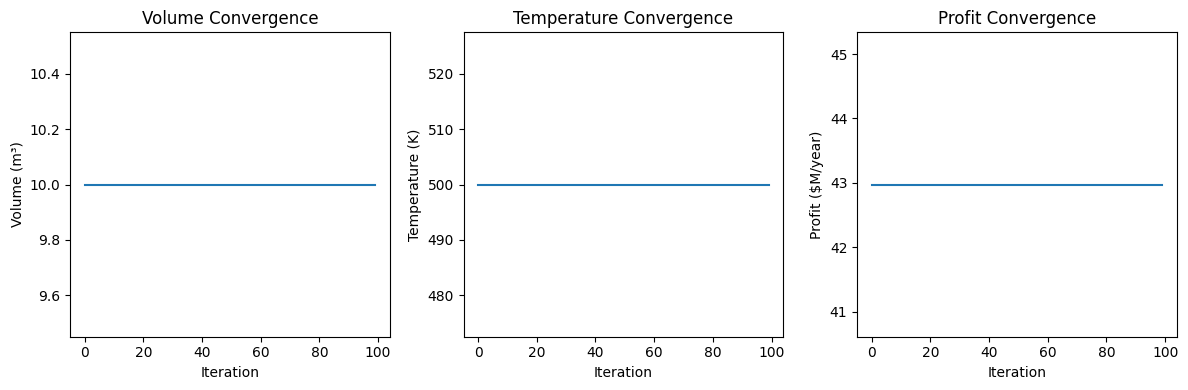

In [13]:
# Visualize optimization trajectory
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

V_hist = [h[0] for h in history]
T_hist = [h[1] for h in history]
profit_hist = [h[2] for h in history]

axes[0].plot(V_hist)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Volume (m³)')
axes[0].set_title('Volume Convergence')

axes[1].plot(T_hist)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Temperature (K)')
axes[1].set_title('Temperature Convergence')

axes[2].plot([p/1e6 for p in profit_hist])
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Profit ($M/year)')
axes[2].set_title('Profit Convergence')

plt.tight_layout()
plt.show()

## 6. Sensitivity Analysis

Gradients tell us how sensitive the economics are to design changes. This is valuable for understanding which parameters matter most.

In [14]:
pe = ProcessEconomics()

# Base case
V = jnp.array(2.0)
T = jnp.array(400.0)

print(f"Base Case: V = {float(V):.1f} m³, T = {float(T):.0f} K")
print("=" * 50)

# Calculate gradients of profit w.r.t. design variables
def profit_fn(V, T):
    return pe.annual_profit(V, T)

grad_V = jax.grad(profit_fn, argnums=0)(V, T)
grad_T = jax.grad(profit_fn, argnums=1)(V, T)

print(f"\nProfit Sensitivities:")
print(f"  ∂Profit/∂V = ${float(grad_V):,.0f} per m³")
print(f"  ∂Profit/∂T = ${float(grad_T):,.0f} per K")

# NPV sensitivities
def npv_fn(V, T):
    return pe.npv(V, T)

grad_npv_V = jax.grad(npv_fn, argnums=0)(V, T)
grad_npv_T = jax.grad(npv_fn, argnums=1)(V, T)

print(f"\nNPV Sensitivities:")
print(f"  ∂NPV/∂V = ${float(grad_npv_V):,.0f} per m³")
print(f"  ∂NPV/∂T = ${float(grad_npv_T):,.0f} per K")

Base Case: V = 2.0 m³, T = 400 K



Profit Sensitivities:
  ∂Profit/∂V = $5,440,910 per m³
  ∂Profit/∂T = $409,033 per K



NPV Sensitivities:
  ∂NPV/∂V = $46,321,541 per m³
  ∂NPV/∂T = $3,482,325 per K


In [15]:
# Sensitivity to product price
print("\nSensitivity to Product Price:")
print("-" * 50)

base_profit = profit_fn(V, T)
price_data = []

for price_mult in [0.8, 0.9, 1.0, 1.1, 1.2]:
    pe_temp = ProcessEconomics(prices={"A": 50.0, "B": 200.0 * price_mult})
    profit = pe_temp.annual_profit(V, T)
    change = (float(profit) - float(base_profit)) / float(base_profit) * 100
    price_data.append((200*price_mult, float(profit), change))
    print(f"  B price = ${200*price_mult:.0f}/kmol: Profit = ${float(profit):>10,.0f} ({change:+.1f}%)")


Sensitivity to Product Price:
--------------------------------------------------
  B price = $160/kmol: Profit = $19,992,828 (-30.1%)


  B price = $180/kmol: Profit = $24,296,135 (-15.0%)
  B price = $200/kmol: Profit = $28,599,441 (+0.0%)
  B price = $220/kmol: Profit = $32,902,748 (+15.0%)


  B price = $240/kmol: Profit = $37,206,055 (+30.1%)


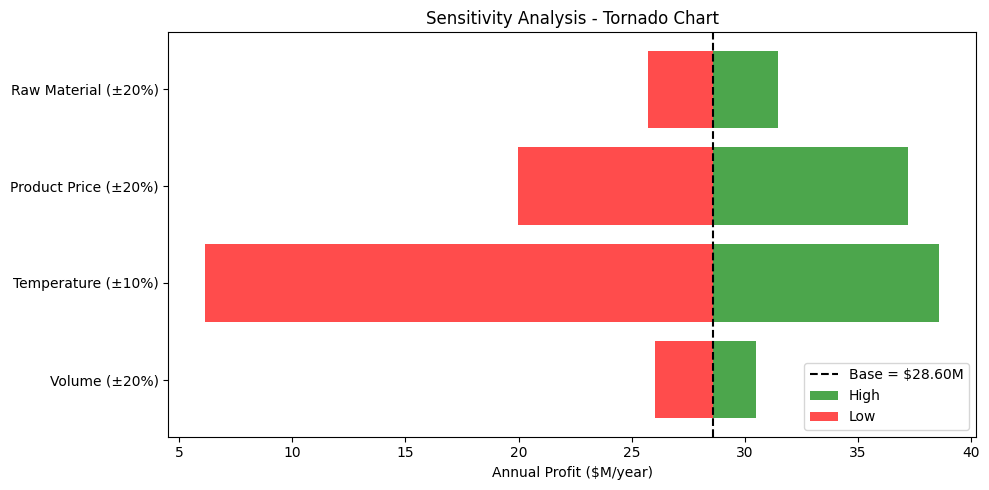

In [16]:
# Tornado chart of sensitivities
fig, ax = plt.subplots(figsize=(10, 5))

# Calculate normalized sensitivities
base_V, base_T = 2.0, 400.0
base_profit_val = float(pe.annual_profit(jnp.array(base_V), jnp.array(base_T)))

sensitivities = []

# Volume ±20%
profit_low = float(pe.annual_profit(jnp.array(base_V * 0.8), jnp.array(base_T)))
profit_high = float(pe.annual_profit(jnp.array(base_V * 1.2), jnp.array(base_T)))
sensitivities.append(('Volume (±20%)', profit_low/1e6, profit_high/1e6))

# Temperature ±10%
profit_low = float(pe.annual_profit(jnp.array(base_V), jnp.array(base_T * 0.9)))
profit_high = float(pe.annual_profit(jnp.array(base_V), jnp.array(base_T * 1.1)))
sensitivities.append(('Temperature (±10%)', profit_low/1e6, profit_high/1e6))

# Product price ±20%
pe_low = ProcessEconomics(prices={"A": 50.0, "B": 160.0})
pe_high = ProcessEconomics(prices={"A": 50.0, "B": 240.0})
profit_low = float(pe_low.annual_profit(jnp.array(base_V), jnp.array(base_T)))
profit_high = float(pe_high.annual_profit(jnp.array(base_V), jnp.array(base_T)))
sensitivities.append(('Product Price (±20%)', profit_low/1e6, profit_high/1e6))

# Raw material price ±20%
pe_low = ProcessEconomics(prices={"A": 40.0, "B": 200.0})
pe_high = ProcessEconomics(prices={"A": 60.0, "B": 200.0})
profit_low = float(pe_low.annual_profit(jnp.array(base_V), jnp.array(base_T)))
profit_high = float(pe_high.annual_profit(jnp.array(base_V), jnp.array(base_T)))
sensitivities.append(('Raw Material (±20%)', profit_high/1e6, profit_low/1e6))  # Note: reversed

# Plot
base_profit_M = base_profit_val / 1e6
labels = [s[0] for s in sensitivities]
y_pos = range(len(labels))

for i, (label, low, high) in enumerate(sensitivities):
    ax.barh(i, high - base_profit_M, left=base_profit_M, color='green', alpha=0.7, label='High' if i==0 else '')
    ax.barh(i, low - base_profit_M, left=base_profit_M, color='red', alpha=0.7, label='Low' if i==0 else '')

ax.axvline(x=base_profit_M, color='black', linestyle='--', label=f'Base = ${base_profit_M:.2f}M')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('Annual Profit ($M/year)')
ax.set_title('Sensitivity Analysis - Tornado Chart')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 7. Process Alternatives Comparison

Compare different design philosophies: conservative, moderate, and aggressive.

In [17]:
alternatives = [
    ("Conservative", 1.0, 350.0),
    ("Moderate", 2.0, 400.0),
    ("Aggressive", 4.0, 450.0),
]

pe = ProcessEconomics()

print("Process Alternatives Comparison:")
print("=" * 90)
print(f"{'Design':12s} {'V(m³)':>6s} {'T(K)':>6s} {'Conv(%)':>8s} "
      f"{'CAPEX($M)':>10s} {'OPEX($M/y)':>11s} {'Profit($M/y)':>13s} {'NPV($M)':>10s}")
print("-" * 90)

results = []
for name, V, T in alternatives:
    V_arr = jnp.array(V)
    T_arr = jnp.array(T)
    
    outlet, info = pe.simulate(V_arr, T_arr)
    capex = pe.capital_cost(V_arr)
    opex = pe.operating_cost(V_arr, T_arr, outlet, info)
    
    conv = float(info["conversion"]["A"]) * 100
    total_capex = float(capex["total_capital"]) / 1e6
    total_opex = float(opex["total_opex"]) / 1e6
    profit = float(pe.annual_profit(V_arr, T_arr)) / 1e6
    npv_val = float(pe.npv(V_arr, T_arr)) / 1e6
    
    results.append((name, V, T, conv, total_capex, total_opex, profit, npv_val))
    print(f"{name:12s} {V:>6.1f} {T:>6.0f} {conv:>8.1f} "
          f"{total_capex:>10.3f} {total_opex:>11.3f} {profit:>13.3f} {npv_val:>10.3f}")

Process Alternatives Comparison:
Design        V(m³)   T(K)  Conv(%)  CAPEX($M)  OPEX($M/y)  Profit($M/y)    NPV($M)
------------------------------------------------------------------------------------------


Conservative    1.0    350     14.7      0.163      14.412        -5.960    -50.735


Moderate        2.0    400     74.7      0.164      14.414        28.599    243.486


Aggressive      4.0    450     96.9      0.165      14.415        41.388    352.361


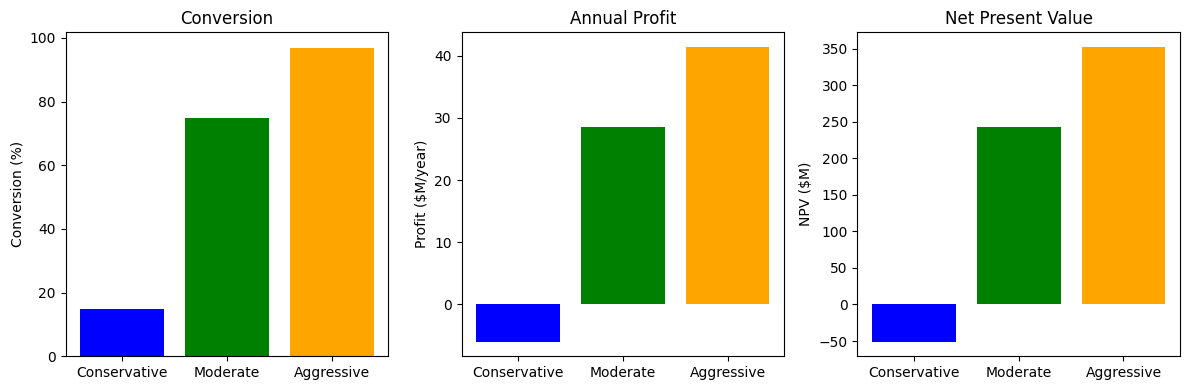

In [18]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

names = [r[0] for r in results]
conversions = [r[3] for r in results]
profits = [r[6] for r in results]
npvs = [r[7] for r in results]

axes[0].bar(names, conversions, color=['blue', 'green', 'orange'])
axes[0].set_ylabel('Conversion (%)')
axes[0].set_title('Conversion')

axes[1].bar(names, profits, color=['blue', 'green', 'orange'])
axes[1].set_ylabel('Profit ($M/year)')
axes[1].set_title('Annual Profit')

axes[2].bar(names, npvs, color=['blue', 'green', 'orange'])
axes[2].set_ylabel('NPV ($M)')
axes[2].set_title('Net Present Value')

plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated comprehensive technoeconomic analysis with difflow:

1. **Equipment Costs** - Cost correlations for reactors, heat exchangers, etc.
2. **Operating Costs** - Raw materials, utilities, labor, maintenance
3. **Profitability Metrics** - NPV, IRR, MSP, annualized profit
4. **Gradient Optimization** - JAX autodiff enables profit maximization
5. **Sensitivity Analysis** - Understand economic drivers

### Key Advantages

- **Differentiable Economics**: All cost calculations are JAX-compatible
- **Integrated Analysis**: Process simulation + economics in one framework
- **Gradient-Based Optimization**: Find optimal designs efficiently
- **Sensitivity Analysis**: Automatic gradients reveal parameter importance